<a href="https://colab.research.google.com/github/argenviahouse-sys/Procesamiento-del-Habla/blob/main/TP2_WebScrapping_PH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 PROCESAMIENTO DEL HABLA

**Escriba aquí su nombre completo.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.




### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.

# 1- WS

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.

# 2- PREPROCESAMIENTO

2.1 Muestra las stop words que tenga tu texto.

2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

2.3 Usando el texto que conseguiste en el punto 1


2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.

2.3.2 Determina la longitud de tu vocabulario.


#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.



In [17]:
# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1 Realizo la instalacion de las librerias que necesito
! pip install requests beautifulsoup4 html5lib

import requests # Ahora es necesario importarlo para usar proxima funcion get url
from bs4 import BeautifulSoup # De la libreria bs4 solamente importa BeautifulSoup que permite leer html

! pip install lxml

url = "https://www.lanacion.com.ar/tecnologia/deteccion-de-estafas-como-usar-la-ia-para-identificar-si-un-mail-o-mensaje-de-texto-fue-generado-por-nid22042026/"

respuesta = requests.get(url)
respuesta.raise_for_status()

sopa = BeautifulSoup(respuesta.text, 'html.parser')


    # Unificamos la búsqueda: intenta h1, si no h2, si no None
header = sopa.find(["h1", "h2"])

if header:
        print(f"{header.name.upper()}: {header.get_text(strip=True)}")
else:
        print("No se encontraron encabezados H1 o H2.")

    # Extraer todo el texto limpio en una sola variable
texto_final = sopa.get_text(separator=" ", strip=True)
print("\nVista previa del contenido:", texto_final[:200], "...")


H1: Detección de estafas: cómo usar la IA para identificar si un mail o mensaje de texto fue generado por un bot para estafa

Vista previa del contenido: Detección de estafas: cómo usar la IA para identificar si un mail o mensaje de texto fue generado por un bot para estafarte - LA NACION CERRAR CERRAR SECCIONES Inicio Secciones Foodit Club LN Mi cuent ...


In [18]:
sopa.find("h1").get_text()

'Detección de estafas: cómo usar la IA para identificar si un mail o mensaje de texto fue generado por un bot para estafa'

In [19]:
sopa.get_text()

"Detección de estafas: cómo usar la IA para identificar si un mail o mensaje de texto fue generado por un bot para estafarte - LA NACION\n\nCERRARCERRARSECCIONESInicioSeccionesFooditClub LNMi cuentaBuscá en LA NACION...LN 104.9 + MúsicaÚltimas noticiasTránsito y transporteClimaLA NACION DataPolíticaEconomíaFuturiaDólar HoyCampoPropiedadesComercio ExteriorMovilidadÍndicesEl MundoEstados UnidosSociedadBuenos AiresSeguridadEducaciónCulturaComunidadBienestarCienciaHablemos de todoOpiniónEditorialesColumnistasCartas de SuscriptoresDeportesFútbolRugbyTenisCanchallenaLifestyleLN JuegosTurismoTecnologíaHoróscopoFeriadosLoterías y quinielasPodcastsModa y BellezaEspectáculosQué sale?Cartelera de cineCartelera de teatroEdición ImpresaAcceso PDFEditorialesConversaciones de domingoSábadoIdeasCarta de lectoresAvisos fúnebresAvisos socialesRevistasRevista OHLALÁ!Revista ¡HOLA!Revista LugaresRevista LivingRevista Rolling StoneRevista JardínLN JuegosSuscriptoresMis notasClub LA NACIONcanchallenaFooditB

In [20]:
sopa.find_all("h2")

[<h2 class="com-subhead --bajada --m-xs-">La inteligencia artificial puede ayudar a identificar cualquier intento de phishing en tan solo segundos; ¿cómo detectar una estafa?</h2>,
 <h2 class="com-title --font-primary --xl --font-extra">Usar la IA para analizar mails o mensajes</h2>,
 <h2 class="com-title --font-primary --xl --font-extra">Usar detectores de “texto generado por IA”</h2>,
 <h2 class="com-title --font-primary --xl --font-extra">Analizar enlaces sospechosos con IA</h2>,
 <h2 class="com-title --font-primary --xl --font-extra">Usar criterio de seguridad propio</h2>,
 <h2 class="com-title --font-primary --xl --font-extra">¿Qué hacer si la IA detecta una estafa?</h2>]

In [21]:
sopa.find_all("iframe")

[<iframe height="0" src="https://www.googletagmanager.com/ns.html?id=GTM-GHV6" style="display:none;visibility:hidden" width="0"></iframe>]

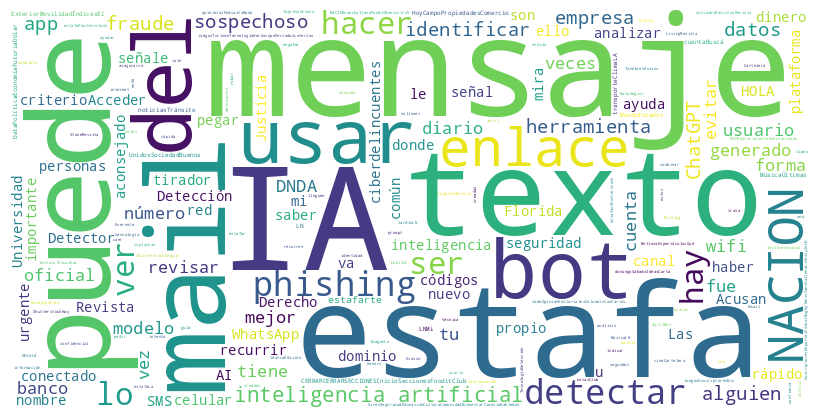

In [23]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


# Usamos el texto completo
full_text = sopa.get_text()

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(full_text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [27]:

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer


# 1. Descargar el recurso de stopwords (necesario en cada sesión de Colab) [2, 5]
nltk.download('stopwords')

# 2. Definir el conjunto de palabras vacías en español
# Esta lista incluye términos funcionales como "el", "de", "un", "con" [5]
stopwords_es = set(stopwords.words('spanish'))

# 3. Preparar el texto (suponiendo que tu variable es full_text)
# Es fundamental pasar todo a minúsculas para que la comparación sea efectiva [5, 6]
palabras_en_texto = full_text.lower().split()

# 4. Filtrar las palabras para identificar cuáles son stop words
# Recorremos el texto y guardamos solo las que están en la lista oficial
stop_words_detectadas = [w for w in palabras_en_texto if w in stopwords_es]

# 5. Mostrar los resultados
# Usamos set() para ver la lista de términos únicos sin repeticiones
print("Stop words identificadas en tu texto:")
print(set(stop_words_detectadas))

# Opcional: Mostrar cuántas hay en total
print(f"\nSe encontraron {len(stop_words_detectadas)} stop words en total.")


Stop words identificadas en tu texto:
{'tu', 'qué', 'estado', 'estas', 'pero', 'muy', 'con', 'nos', 'las', 'fue', 'los', 'de', 'ya', 'esta', 'o', 'en', 'y', 'esté', 'por', 'algo', 'ni', 'le', 'también', 'mi', 'al', 'es', 'nada', 'hasta', 'tiene', 'que', 'hay', 'como', 'todos', 'lo', 'a', 'su', 'más', 'una', 'son', 'sus', 'estos', 'la', 'sobre', 'no', 'donde', 'este', 'para', 'del', 'el', 'uno', 'se', 'un', 'sin'}

Se encontraron 462 stop words en total.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


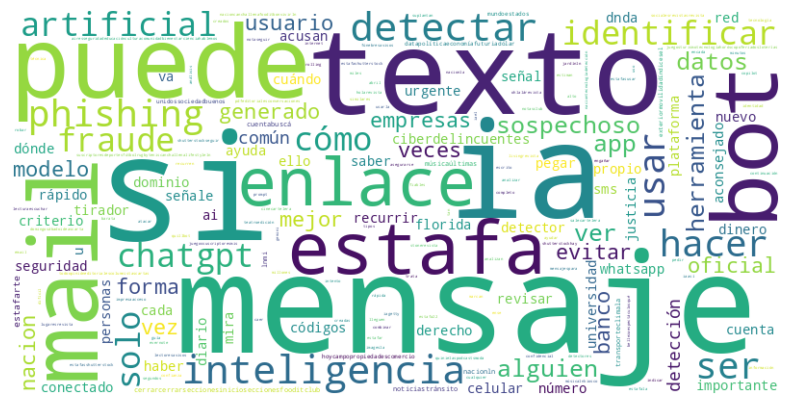

In [28]:
import re
import string
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud

# 1. Configuración de recursos (Unidad 3)
nltk.download('stopwords')
stopwords_es = set(stopwords.words('spanish'))

# 2. Definición de limpieza técnica (Basado en fuentes [1-3])
def limpiar_para_nube(texto):
    # Pasar a minúsculas
    texto = texto.lower()

    # Eliminar signos de puntuación (Fuente [1])
    texto = ''.join(c for c in texto if c not in string.punctuation)

    # Eliminar caracteres extraños y emojis (Fuente [1, 2])
    # La expresión r'[^\w\s,]' busca lo que NO sea letra, número, espacio o coma
    texto = re.sub(r'[^\w\s,]', '', texto)

    # Tokenizar y quitar stop-words (Fuente [3])
    palabras = texto.split()
    filtradas = [p for p in palabras if p not in stopwords_es]

    # Unir nuevamente en un string separado por espacios para la nube
    return ' '.join(filtradas)

# 3. Procesar el texto extraído previamente
texto_final = limpiar_para_nube(full_text)

# 4. Crear y mostrar la nube de palabras (Unidad 0)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap='viridis'
).generate(texto_final)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [36]:
import nltk
import re
import string
import pandas as pd
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer

# Download the 'punkt' resource if not already downloaded, specifically for Spanish
nltk.download('punkt')
nltk.download('punkt_tab') # Download punkt_tab for Spanish

# 1. Segmentación: Descomponer el texto en oraciones
# Es necesario el recurso 'punkt' descargado anteriormente y especificar el idioma
oraciones = sent_tokenize(full_text, language='spanish')

# 2. Limpieza y Preprocesamiento (Unidad 3)
def preprocesar_oracion(texto):
    texto = texto.lower() # Normalización a minúsculas [5]
    # Eliminar signos de puntuación y caracteres extraños [5, 6]
    texto = re.sub(r'[^\u200B-\u200D\uFEFF\w\s,]', '', texto) # Updated regex to handle zero-width spaces
    return texto

# Aplicamos la limpieza a cada oración del discurso
oraciones_limpias = [preprocesar_oracion(sent) for sent in oraciones]

# 3. Crear la Matriz Documento-Vocabulario (Bag of Words)
# Utilizamos las stopwords de NLTK ya cargadas (stopwords_es)
vectorizador = CountVectorizer(stop_words=list(stopwords_es))

# Ajustar y transformar las oraciones en la matriz
matriz_bow = vectorizador.fit_transform(oraciones_limpias)

# 4. Visualización de la matriz (como DataFrame para mayor claridad)
vocabulario = vectorizador.get_feature_names_out()
df_matriz = pd.DataFrame(matriz_bow.toarray(), columns=vocabulario)

print(f"Se han procesado {len(oraciones)} oraciones.")
print("Muestra de la matriz documento-vocabulario:")
print(df_matriz.head())

Se han procesado 28 oraciones.
Muestra de la matriz documento-vocabulario:
   100  1049  2026  202610044  2027  2inteligencia  60  abril  abrirlo  \
0    0     2     0          1     0              0   0      1        0   
1    0     0     0          0     0              0   0      0        0   
2    0     0     0          0     0              0   0      0        0   
3    0     0     0          0     0              0   0      0        0   
4    0     0     0          0     0              0   0      0        0   

   absorbido  ...  vez  viajáspaso  videos  virtualesfuturiaseguí  volver  \
0          0  ...    1           0       0                      0       0   
1          0  ...    0           0       0                      0       0   
2          0  ...    1           0       0                      0       0   
3          0  ...    0           0       0                      0       0   
4          0  ...    0           0       0                      0       0   

   web  whatsapp 

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [38]:
# 1. Obtener la lista de términos únicos (vocabulario)
# La función get_feature_names_out() extrae las palabras que forman las columnas de tu matriz
vocabulario = vectorizador.get_feature_names_out()

# 2. Determinar la longitud
# Usamos la función estándar len() de Python para contar los elementos
longitud_vocabulario = len(vocabulario)

# 3. Mostrar el resultado
print(f"La longitud total del vocabulario es: {longitud_vocabulario} palabras únicas.")

# Opcional: Mostrar una muestra de las palabras que componen este vocabulario
print("\nPrimeras 20 palabras del vocabulario ordenadas alfabéticamente:")
print(vocabulario[:20])


La longitud total del vocabulario es: 456 palabras únicas.

Primeras 20 palabras del vocabulario ordenadas alfabéticamente:
['100' '1049' '2026' '202610044' '2027' '2inteligencia' '60' 'abril'
 'abrirlo' 'absorbido' 'acceder' 'accedió' 'accionen' 'acciones'
 'aconsejado' 'activar' 'actuar' 'actúa' 'acusan' 'afinar']


In [39]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Configurar y aplicar el vectorizador TF-IDF
# Usamos las oraciones_limpias que generamos en el paso anterior
# Incluimos nuevamente las stopwords para asegurar la limpieza en la ponderación
tfidf_vectorizer = TfidfVectorizer(stop_words=list(stopwords_es))

# 2. Ajustar y transformar el corpus (tus oraciones)
# Esta función calcula automáticamente el TF (frecuencia) y el IDF (importancia inversa)
tfidf_matrix = tfidf_vectorizer.fit_transform(oraciones_limpias)

# 3. Visualizar la matriz resultante como un DataFrame
# Esto permite ver el "peso" numérico que recibió cada palabra en cada oración
vocabulario_tfidf = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocabulario_tfidf)

print("Matriz TF-IDF generada con éxito.")
print("\nMuestra de los pesos TF-IDF (Primeras 5 oraciones):")
print(df_tfidf.head())

Matriz TF-IDF generada con éxito.

Muestra de los pesos TF-IDF (Primeras 5 oraciones):
   100      1049  2026  202610044  2027  2inteligencia   60     abril  \
0  0.0  0.175692   0.0   0.087846   0.0            0.0  0.0  0.087846   
1  0.0  0.000000   0.0   0.000000   0.0            0.0  0.0  0.000000   
2  0.0  0.000000   0.0   0.000000   0.0            0.0  0.0  0.000000   
3  0.0  0.000000   0.0   0.000000   0.0            0.0  0.0  0.000000   
4  0.0  0.000000   0.0   0.000000   0.0            0.0  0.0  0.000000   

   abrirlo  absorbido  ...       vez  viajáspaso  videos  \
0      0.0        0.0  ...  0.071273         0.0     0.0   
1      0.0        0.0  ...  0.000000         0.0     0.0   
2      0.0        0.0  ...  0.143965         0.0     0.0   
3      0.0        0.0  ...  0.000000         0.0     0.0   
4      0.0        0.0  ...  0.000000         0.0     0.0   

   virtualesfuturiaseguí  volver  web  whatsapp  wifi  wifi4whatsapp  \
0                    0.0     0.0  0.0   0

# APRENDIZAJE Y CONCLUSIONES
1. La Adquisición de Datos: No todas las webs son iguales
La primera gran conclusión es que la técnica de extracción depende de la arquitectura del sitio
.
Webs Estáticas vs. Dinámicas: Si el discurso está en el HTML plano, BeautifulSoup es suficiente y eficiente
. Sin embargo, si el contenido se genera tras la carga (JavaScript), es obligatorio usar herramientas como Selenium para que la máquina "espere" a que el texto aparezca
.
Robustez del Código: Es vital implementar manejos de excepciones (try-except) y verificar el estado de la solicitud (raise_for_status()) para asegurar que el flujo no se rompa por problemas de red o URLs inexistentes
.
2. Preprocesamiento: La clave está en reducir el "ruido"
El preprocesamiento no es un paso opcional, sino el 80% del trabajo en IA aplicada al lenguaje
.
Normalización y Limpieza: Pasar a minúsculas y eliminar signos de puntuación es esencial para que la computadora no trate a "Paz" y "paz" como conceptos diferentes
. Las expresiones regulares son la herramienta más potente para limpiar "ruido" no textual como emojis o símbolos técnicos
.
El Impacto de las Stop-words: Eliminar palabras funcionales permite que los modelos se centren en los términos con carga semántica
. Sin esta limpieza, tu nube de palabras y tus matrices estarían dominadas por artículos y preposiciones ("el", "de", "que") que no aportan información sobre el tema del discurso
.
